In [28]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


In [29]:
model = models.swin_t(weights=None)

num_classes = 7
in_features = model.head.in_features

model.head = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, num_classes)
)

model = model.to(device)

print("Swin-Tiny architecture created.")
print(model.head)

[W1005 18:26:47.652812819 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 20971520 bytes (free: 4980736, total: 8082096128).
[W1005 18:26:47.652898954 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 20971520 bytes (free: 4980736, total: 8082096128).


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 7.53 GiB of which 4.75 MiB is free. Process 13444 has 322.00 MiB memory in use. Including non-PyTorch memory, this process has 700.00 MiB memory in use. Process 15044 has 804.00 MiB memory in use. Process 15259 has 4.85 GiB memory in use. Process 15324 has 862.00 MiB memory in use. Of the allocated memory 600.56 MiB is allocated by PyTorch, and 1.44 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Create Swin-Tiny architecture
model = models.swin_t(weights=None)

# HAM10000 has 7 classes
num_classes = 7

# Replace original ImageNet classification head
in_features = model.head.in_features

model.head = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, num_classes)
)

# Move model to GPU/CPU
model = model.to(device)

print("\n✅ Swin-Tiny architecture created.")
print("Model type:", type(model).__name__)
print("Classifier:", model.head)

Device: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU

✅ Swin-Tiny architecture created.
Model type: SwinTransformer
Classifier: Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=768, out_features=7, bias=True)
)


In [ ]:
checkpoint_path = "../models/swin_tiny_best.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

print("Checkpoint loaded.")
print("Checkpoint type:", type(checkpoint))

Checkpoint loaded.
Checkpoint type: <class 'collections.OrderedDict'>


In [ ]:
# Load the actual trained weights from the checkpoint

if isinstance(checkpoint, dict):

    if "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]

    elif "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]

    else:
        state_dict = checkpoint

else:
    state_dict = checkpoint

model.load_state_dict(state_dict)

model.eval()

print("✅ Trained Swin-Tiny weights loaded successfully.")

✅ Trained Swin-Tiny weights loaded successfully.


In [ ]:
print("Model ready:", type(model).__name__)

Model ready: SwinTransformer


2D weight layers found: 52

Processing: features.1.0.attn.qkv.weight
Shape: (288, 96)


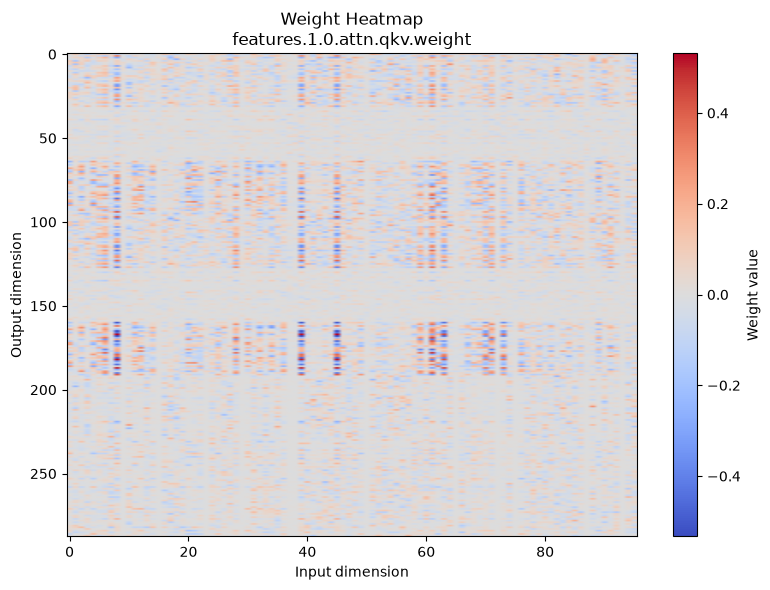

Saved: ../results/weight_heatmaps/features_1_0_attn_qkv_weight.png

Processing: features.1.0.attn.proj.weight
Shape: (96, 96)


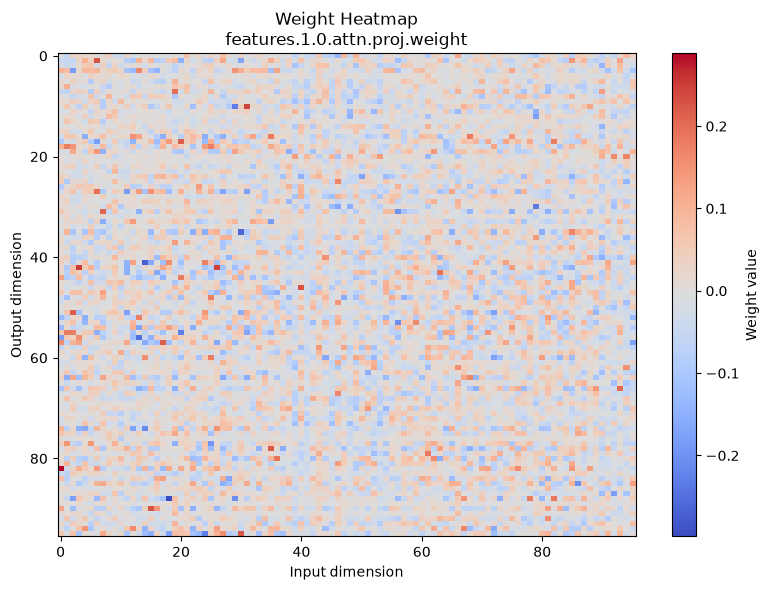

Saved: ../results/weight_heatmaps/features_1_0_attn_proj_weight.png

Processing: features.1.0.mlp.0.weight
Shape: (384, 96)


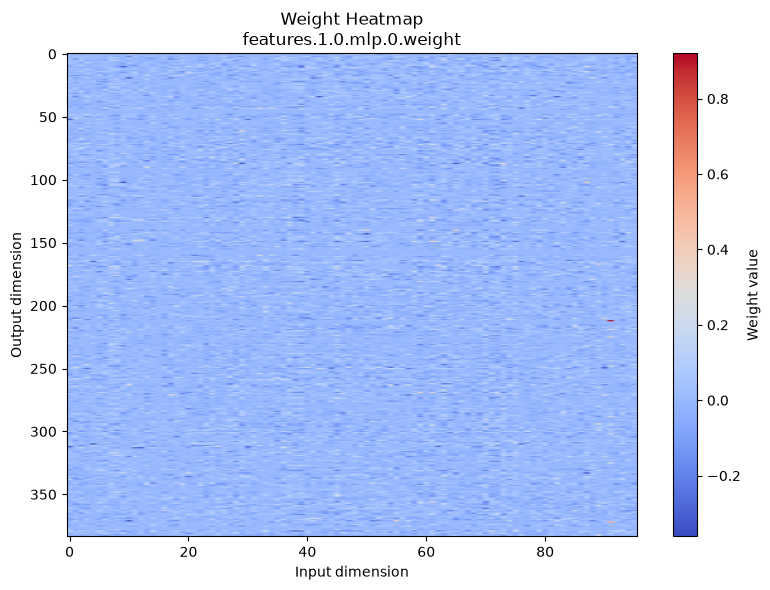

Saved: ../results/weight_heatmaps/features_1_0_mlp_0_weight.png

Processing: features.1.0.mlp.3.weight
Shape: (96, 384)


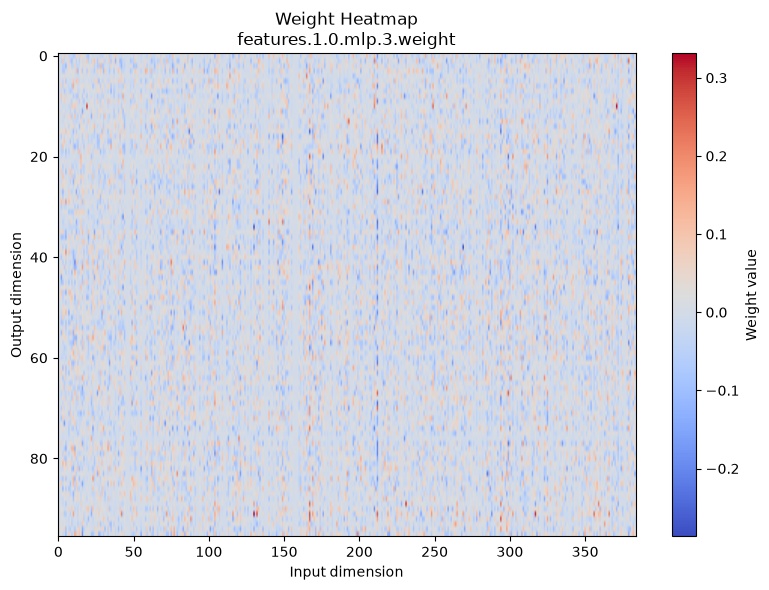

Saved: ../results/weight_heatmaps/features_1_0_mlp_3_weight.png

Processing: features.1.1.attn.qkv.weight
Shape: (288, 96)


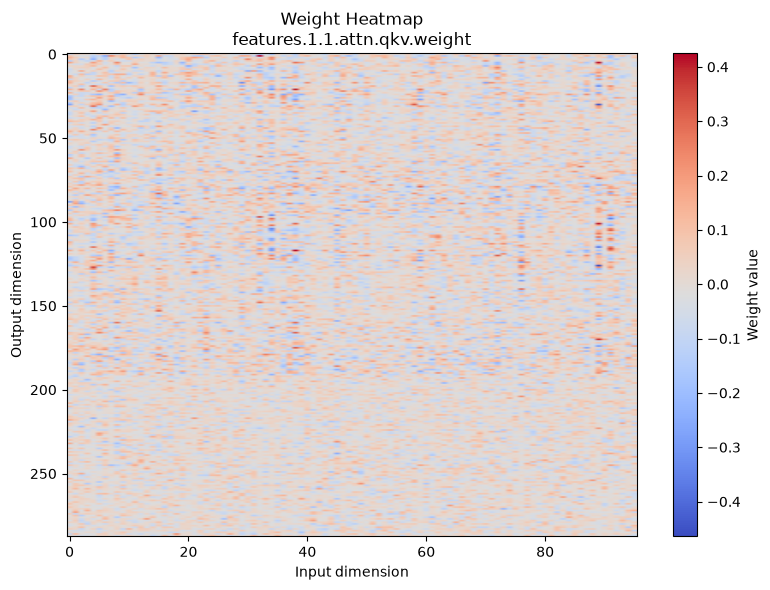

Saved: ../results/weight_heatmaps/features_1_1_attn_qkv_weight.png

Processing: features.1.1.attn.proj.weight
Shape: (96, 96)


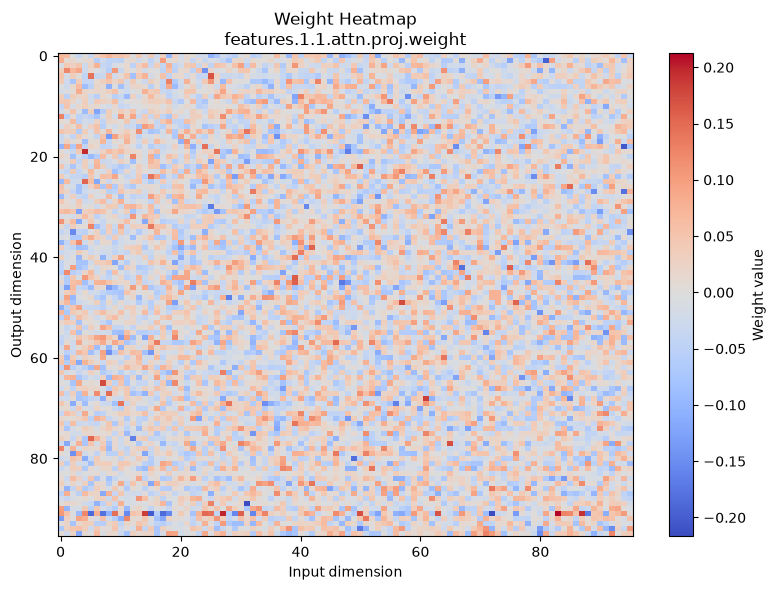

Saved: ../results/weight_heatmaps/features_1_1_attn_proj_weight.png

✅ Phase 23B heatmap generation completed.


In [ ]:
# ============================================================
# PHASE 23B — WEIGHT HEATMAPS
# ============================================================

import matplotlib.pyplot as plt
import os

# Folder to save heatmaps
heatmap_dir = "../results/weight_heatmaps"
os.makedirs(heatmap_dir, exist_ok=True)

# Store model parameters once
parameters = dict(model.named_parameters())

# Find 2D weight matrices
selected_layers = []

for name, param in model.named_parameters():

    if "weight" in name and param.requires_grad and param.ndim == 2:
        selected_layers.append(name)

print("2D weight layers found:", len(selected_layers))

# Generate heatmaps for first 6 layers
for name in selected_layers[:6]:

    print(f"\nProcessing: {name}")

    # Get weight tensor
    weight = parameters[name]

    # Detach from computation graph → CPU → NumPy
    weight = weight.detach().cpu().numpy()

    print("Shape:", weight.shape)

    # Create heatmap
    plt.figure(figsize=(8, 6))

    plt.imshow(
        weight,
        aspect="auto",
        cmap="coolwarm"
    )

    plt.colorbar(label="Weight value")

    plt.title(f"Weight Heatmap\n{name}")
    plt.xlabel("Input dimension")
    plt.ylabel("Output dimension")

    plt.tight_layout()

    # Save image
    filename = name.replace(".", "_") + ".png"
    save_path = os.path.join(heatmap_dir, filename)

    plt.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print("Saved:", save_path)

print("\n✅ Phase 23B heatmap generation completed.")

# Phase 23A & 23B — Weight Analysis and Heatmap Visualization

In this phase, the trained Swin-Tiny model was loaded and its learned parameters were analyzed.

## Weight Analysis

A neural network contains millions of learnable parameters called weights and biases. A weight determines how strongly information is passed between neurons/features.

For each weight layer, we analyzed:
- Minimum and maximum weight
- Mean and standard deviation
- Mean absolute weight
- Median absolute weight
- Number of zero weights
- Total number of parameters

Weight magnitude was calculated using `|weight|`. Small-magnitude weights are potential candidates for pruning, but a small weight is not automatically considered useless.

Since Swin-Tiny contains millions of parameters, exact global percentile calculation using `torch.quantile()` was memory-intensive. Therefore, representative samples of weights were used to estimate the weight-magnitude distribution.

## Weight Heatmaps

A weight heatmap is a visual representation of numerical model weights using colors.

- Red/orange → positive weights
- Blue → negative weights
- White/light colors → weights close to zero

The heatmaps generated in this phase represent learned model parameters, NOT regions of the input skin-lesion image.

Examples of analyzed Swin-Tiny layers included:
- `attn.qkv.weight` — weights used to generate Query, Key and Value representations in the attention mechanism.
- `attn.proj.weight` — weights used in the attention output projection.
- `mlp.0.weight` and `mlp.3.weight` — weights belonging to the Multi-Layer Perceptron inside a Swin Transformer block.

Important distinction:
- Weight heatmap → visualizes learned model parameters.
- Feature map → visualizes activations/features produced by an input image.
- Grad-CAM → highlights image regions that contribute to a model prediction.

The heatmaps are used for understanding the distribution of learned weights. They are not sufficient by themselves to determine which weights should be removed.

## Current Status

Phase 23A — Weight inspection: COMPLETED
Phase 23B — Weight heatmap visualization: COMPLETED

Next: Phase 23C — Weight importance analysis and pruning.

In [ ]:
# ============================================================
# PHASE 23C — BASELINE WEIGHT ANALYSIS
# ============================================================

import torch
import pandas as pd

layer_analysis = []

for name, param in model.named_parameters():

    if "weight" in name and param.requires_grad:

        w = param.detach()

        abs_w = w.abs()

        total = w.numel()
        zeros = (w == 0).sum().item()

        layer_analysis.append({
            "layer": name,
            "parameters": total,
            "zero_weights": zeros,
            "sparsity_percent": (zeros / total) * 100,
            "mean_abs_weight": abs_w.mean().item(),
            "median_abs_weight": abs_w.median().item(),
            "min_abs_weight": abs_w.min().item(),
            "max_abs_weight": abs_w.max().item()
        })

layer_analysis_df = pd.DataFrame(layer_analysis)

print("Number of analyzed weight layers:",
      len(layer_analysis_df))

print("\nCurrent overall sparsity:")

total_params = layer_analysis_df["parameters"].sum()
total_zeros = layer_analysis_df["zero_weights"].sum()

overall_sparsity = (total_zeros / total_params) * 100

print(f"{overall_sparsity:.4f}%")

layer_analysis_df

Number of analyzed weight layers: 82

Current overall sparsity:
0.0000%


,layer,parameters,zero_weights,sparsity_percent,mean_abs_weight,median_abs_weight,min_abs_weight,max_abs_weight
0,features.0.0.weight,4608,0,0.0,0.043125,0.034531,6.767704e-06,0.258799
1,features.0.2.weight,96,0,0.0,1.444817,0.966776,1.855024e-03,4.251256
2,features.1.0.norm1.weight,96,0,0.0,0.718242,0.774582,4.753127e-05,1.578722
3,features.1.0.attn.qkv.weight,27648,0,0.0,0.046236,0.026562,1.894096e-07,0.533043
4,features.1.0.attn.proj.weight,9216,0,0.0,0.037092,0.026738,3.490932e-06,0.298414
...,...,...,...,...,...,...,...,...
77,features.7.1.norm2.weight,768,0,0.0,2.354996,2.273113,1.813582e-03,5.360744
78,features.7.1.mlp.0.weight,2359296,0,0.0,0.038768,0.032374,1.448017e-08,0.584206
79,features.7.1.mlp.3.weight,2359296,0,0.0,0.041720,0.034690,4.256801e-09,1.638299
80,norm.weight,768,0,0.0,2.008732,2.004053,9.858832e-04,4.594053


In [ ]:
# ============================================================
# PHASE 23C — MAGNITUDE-BASED WEIGHT PRUNING
# ============================================================
#
# GOAL:
# Remove low-importance weights from the trained Swin-Tiny model.
#
# TERMINOLOGY:
#
# Magnitude:
#   Absolute value of a weight: |w|.
#   Example: |-0.8| = 0.8.
#
# Magnitude-based pruning:
#   We assume very small-magnitude weights contribute less than
#   large-magnitude weights and test whether they can be removed.
#
# Sparsity:
#   Percentage of weights that are zero.
#   Example: 20% sparsity means 20% of considered weights are zero.
#
# Global pruning:
#   We compare weights across ALL selected prunable layers and remove
#   the globally smallest weights rather than pruning the same
#   percentage independently from every layer.
#
# IMPORTANT:
#   We do NOT modify the original model.
#   Each pruning experiment uses a deepcopy of the trained model.
#
# IMPORTANT:
#   Normalization parameters are excluded because their scaling
#   parameters play a different role and should not be blindly pruned.
# ============================================================

import torch
import copy
import pandas as pd


# ------------------------------------------------------------
# STEP 1 — Decide which parameters are allowed to be pruned.
#
# For this first experiment we prune 2D weight matrices.
# These mainly correspond to Linear layers such as:
#   - attention QKV weights
#   - attention projection weights
#   - MLP weights
#
# We avoid normalization weights and biases.
# ------------------------------------------------------------

def get_prunable_parameters(model):

    prunable = []

    for name, param in model.named_parameters():

        if (
            "weight" in name
            and param.requires_grad
            and param.ndim == 2
            and "norm" not in name.lower()
        ):
            prunable.append((name, param))

    return prunable


prunable = get_prunable_parameters(model)

print("Prunable layers:", len(prunable))

total_prunable_weights = sum(
    param.numel() for _, param in prunable
)

print(f"Total prunable weights: {total_prunable_weights:,}")


# ------------------------------------------------------------
# STEP 2 — Collect a representative sample of weight magnitudes.
#
# Swin-Tiny contains millions of weights, so calculating an exact
# quantile over one huge tensor can exceed PyTorch's quantile limit.
#
# Instead, we sample weights from every prunable layer.
# This gives us an estimated GLOBAL pruning threshold.
# ------------------------------------------------------------

def estimate_global_threshold(model, pruning_percentage):

    samples = []

    MAX_PER_LAYER = 100_000

    for name, param in get_prunable_parameters(model):

        w = param.detach().abs().flatten().cpu()

        if w.numel() > MAX_PER_LAYER:

            indices = torch.randperm(w.numel())[:MAX_PER_LAYER]

            w = w[indices]

        samples.append(w)

    sampled_weights = torch.cat(samples)

    threshold = torch.quantile(
        sampled_weights,
        pruning_percentage / 100
    )

    return threshold.item()


# ------------------------------------------------------------
# STEP 3 — Apply the threshold.
#
# MASK:
#   True/1  -> keep the weight
#   False/0 -> prune the weight
#
# Example:
#
# weights = [0.8, 0.002, -0.7]
#
# threshold = 0.01
#
# mask = [1, 0, 1]
#
# result = [0.8, 0, -0.7]
#
# This is UNSTRUCTURED PRUNING because individual weights are
# removed rather than entire neurons/channels/layers.
# ------------------------------------------------------------

def prune_model(original_model, pruning_percentage):

    # Copy protects our original trained model.
    pruned_model = copy.deepcopy(original_model)

    threshold = estimate_global_threshold(
        pruned_model,
        pruning_percentage
    )

    with torch.no_grad():

        for name, param in get_prunable_parameters(pruned_model):

            mask = param.abs() > threshold

            param.mul_(mask)

    return pruned_model, threshold


# ------------------------------------------------------------
# STEP 4 — Measure actual sparsity after pruning.
#
# Since the threshold is estimated using sampling, the final sparsity
# may be slightly different from exactly 10%, 20%, or 30%.
# ------------------------------------------------------------

def calculate_sparsity(model):

    zero_weights = 0
    total_weights = 0

    for name, param in get_prunable_parameters(model):

        total_weights += param.numel()

        zero_weights += (
            param.detach() == 0
        ).sum().item()

    sparsity = (
        zero_weights / total_weights
    ) * 100

    return sparsity


# ------------------------------------------------------------
# STEP 5 — Test several pruning levels.
#
# We are NOT evaluating classification performance yet.
# Here we only verify that pruning actually works.
# ------------------------------------------------------------

pruning_levels = [10, 20, 30]

pruning_results = []

pruned_models = {}

for level in pruning_levels:

    print("\n" + "=" * 60)
    print(f"PRUNING TARGET: {level}%")
    print("=" * 60)

    pruned_model, threshold = prune_model(
        model,
        level
    )

    actual_sparsity = calculate_sparsity(
        pruned_model
    )

    pruning_results.append({
        "target_pruning_percent": level,
        "threshold": threshold,
        "actual_sparsity_percent": actual_sparsity
    })

    # Keep temporarily so we can evaluate them next.
    pruned_models[level] = pruned_model

    print(f"Threshold       : {threshold:.8f}")
    print(f"Actual sparsity : {actual_sparsity:.2f}%")


# ------------------------------------------------------------
# STEP 6 — Show experiment summary.
# ------------------------------------------------------------

pruning_df = pd.DataFrame(pruning_results)

print("\nPRUNING SUMMARY")
display(pruning_df)

print("\n✅ Phase 23C pruning completed.")
print("Original trained model remains unchanged.")

Prunable layers: 52
Total prunable weights: 27,432,192

PRUNING TARGET: 10%
Threshold       : 0.00555714
Actual sparsity : 9.39%

PRUNING TARGET: 20%
Threshold       : 0.01149640
Actual sparsity : 19.18%

PRUNING TARGET: 30%
Threshold       : 0.01777640
Actual sparsity : 29.12%

PRUNING SUMMARY


,target_pruning_percent,threshold,actual_sparsity_percent
0,10,0.005557,9.388007
1,20,0.011496,19.178653
2,30,0.017776,29.118060



✅ Phase 23C pruning completed.
Original trained model remains unchanged.


In [30]:
# ============================================================
# PHASE 23D — EVALUATE PRUNED MODELS
# ============================================================
#
# REASONING:
# Pruning is useful only if we can remove parameters while
# maintaining acceptable classification performance.
#
# Therefore, we compare:
#   1. Original Swin-Tiny
#   2. 10% pruned Swin-Tiny
#   3. 20% pruned Swin-Tiny
#   4. 30% pruned Swin-Tiny
#
# We use the SAME validation set for every model so the comparison
# is fair.
#
# Important metrics:
#   Accuracy          -> overall percentage of correct predictions
#   Balanced Accuracy -> average recall across classes
#   Macro Precision   -> precision averaged equally across classes
#   Macro Recall      -> recall averaged equally across classes
#   Macro F1          -> F1 averaged equally across classes
#
# Macro F1 is particularly important here because HAM10000 is
# strongly class-imbalanced.
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import torch
import pandas as pd


def evaluate_model(model_to_evaluate, val_loader, device):

    model_to_evaluate.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_to_evaluate(images)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    balanced_accuracy = balanced_accuracy_score(
        all_labels,
        all_predictions
    )

    precision = precision_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy * 100,
        "balanced_accuracy": balanced_accuracy * 100,
        "macro_precision": precision * 100,
        "macro_recall": recall * 100,
        "macro_f1": f1 * 100
    }


# ------------------------------------------------------------
# Evaluate ORIGINAL model
# ------------------------------------------------------------

print("=" * 70)
print("Evaluating ORIGINAL model")
print("=" * 70)

original_metrics = evaluate_model(
    model,
    val_loader,
    device
)

print(
    f"Accuracy          : {original_metrics['accuracy']:.2f}%"
)
print(
    f"Balanced Accuracy : {original_metrics['balanced_accuracy']:.2f}%"
)
print(
    f"Macro Precision   : {original_metrics['macro_precision']:.2f}%"
)
print(
    f"Macro Recall      : {original_metrics['macro_recall']:.2f}%"
)
print(
    f"Macro F1          : {original_metrics['macro_f1']:.2f}%"
)


# ------------------------------------------------------------
# Evaluate PRUNED models
# ------------------------------------------------------------

evaluation_results = []

evaluation_results.append({
    "model": "Original",
    "pruning_percent": 0,
    **original_metrics
})


for level, pruned_model in pruned_models.items():

    print("\n" + "=" * 70)
    print(f"Evaluating {level}% PRUNED model")
    print("=" * 70)

    metrics = evaluate_model(
        pruned_model,
        val_loader,
        device
    )

    print(
        f"Accuracy          : {metrics['accuracy']:.2f}%"
    )
    print(
        f"Balanced Accuracy : {metrics['balanced_accuracy']:.2f}%"
    )
    print(
        f"Macro Precision   : {metrics['macro_precision']:.2f}%"
    )
    print(
        f"Macro Recall      : {metrics['macro_recall']:.2f}%"
    )
    print(
        f"Macro F1          : {metrics['macro_f1']:.2f}%"
    )

    evaluation_results.append({
        "model": f"{level}% Pruned",
        "pruning_percent": level,
        **metrics
    })


# ------------------------------------------------------------
# Create comparison table
# ------------------------------------------------------------

pruning_evaluation_df = pd.DataFrame(
    evaluation_results
)

print("\n" + "=" * 70)
print("ORIGINAL VS PRUNED MODEL COMPARISON")
print("=" * 70)

display(
    pruning_evaluation_df.round(2)
)

print("\n✅ Phase 23D evaluation completed.")

Evaluating ORIGINAL model


NameError: name 'val_loader' is not defined